# BA820 Project M4: Mapping the Economic Burden of Childcare Across US Counties

**Project Title**: Mapping the Economic Burden of Childcare Across US Counties

**Section and Team Number**: B1 Team 9

**Name**: Li-Hsin Chang




## Upload Data

In [83]:
import pandas as pd
url = "https://raw.githubusercontent.com/cindych12/BA820-project/refs/heads/main/childcare_costs.csv"
df = pd.read_csv(url)
df.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,21.55,4.07,80.92,81.40,104.95,104.95,85.92,83.45,83.45,81.40
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,21.96,5.19,83.42,85.68,105.11,105.11,87.59,87.39,87.39,85.68
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,21.28,4.13,85.92,89.96,105.28,105.28,89.26,91.33,91.33,89.96
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,22.80,4.77,88.43,94.25,105.45,105.45,90.93,95.28,95.28,94.25
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,22.88,4.84,90.93,98.53,105.61,105.61,92.60,99.22,99.22,98.53


In [84]:
url="https://raw.githubusercontent.com/cindych12/BA820-project/refs/heads/main/counties.csv"
df2 = pd.read_csv(url)
df2.head()

,county_fips_code,county_name,state_name,state_abbreviation
0,1001,Autauga County,Alabama,AL
1,1003,Baldwin County,Alabama,AL
2,1005,Barbour County,Alabama,AL
3,1007,Bibb County,Alabama,AL
4,1009,Blount County,Alabama,AL


## Data Preprocessing & Understanding

### Merge Data




In [85]:
df_merged = df.merge(df2,on="county_fips_code",how="left")
df_merged.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,81.40,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,85.68,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,89.96,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,94.25,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,98.53,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL


### Data Cleaning

In [86]:
df_merged.columns

Index(['county_fips_code', 'study_year', 'unr_16', 'funr_16', 'munr_16',
       'unr_20to64', 'funr_20to64', 'munr_20to64', 'flfpr_20to64',
       'flfpr_20to64_under6', 'flfpr_20to64_6to17',
       'flfpr_20to64_under6_6to17', 'mlfpr_20to64', 'pr_f', 'pr_p', 'mhi_2018',
       'me_2018', 'fme_2018', 'mme_2018', 'total_pop', 'one_race',
       'one_race_w', 'one_race_b', 'one_race_i', 'one_race_a', 'one_race_h',
       'one_race_other', 'two_races', 'hispanic', 'households',
       'h_under6_both_work', 'h_under6_f_work', 'h_under6_m_work',
       'h_under6_single_m', 'h_6to17_both_work', 'h_6to17_fwork',
       'h_6to17_mwork', 'h_6to17_single_m', 'emp_m', 'memp_m', 'femp_m',
       'emp_service', 'memp_service', 'femp_service', 'emp_sales',
       'memp_sales', 'femp_sales', 'emp_n', 'memp_n', 'femp_n', 'emp_p',
       'memp_p', 'femp_p', 'mcsa', 'mfccsa', 'mc_infant', 'mc_toddler',
       'mc_preschool', 'mfcc_infant', 'mfcc_toddler', 'mfcc_preschool',
       'county_name', 'state_n

In [87]:
childcare = df_merged.copy()

In [88]:
childcare = childcare[
    (childcare["mc_infant"] > 0) &
    (childcare["mhi_2018"] > 0)
]

In [89]:
childcare.isna().sum().sort_values(ascending=False)

,0
mfccsa,251
mfcc_preschool,251
mfcc_infant,251
mfcc_toddler,251
county_fips_code,0
...,...
mc_preschool,0
mc_toddler,0
county_name,0
state_name,0


In [90]:
childcare_clean = childcare.dropna(
    subset=["mfcc_infant", "mfcc_toddler", "mfcc_preschool","mfccsa"]
)

In [91]:
childcare_clean.isna().sum().sort_values(ascending=False)

,0
county_fips_code,0
study_year,0
unr_16,0
funr_16,0
munr_16,0
...,...
mfcc_toddler,0
mfcc_preschool,0
county_name,0
state_name,0


In [92]:
childcare_clean.duplicated(
    subset=["county_fips_code","study_year"]
).sum()

np.int64(0)

In [93]:
childcare_clean.dtypes

,0
county_fips_code,int64
study_year,int64
unr_16,float64
funr_16,float64
munr_16,float64
...,...
mfcc_toddler,float64
mfcc_preschool,float64
county_name,object
state_name,object


In [94]:
childcare_clean.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,81.40,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,85.68,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,89.96,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,94.25,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,98.53,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL


In [95]:
print(childcare_clean.columns)

Index(['county_fips_code', 'study_year', 'unr_16', 'funr_16', 'munr_16',
       'unr_20to64', 'funr_20to64', 'munr_20to64', 'flfpr_20to64',
       'flfpr_20to64_under6', 'flfpr_20to64_6to17',
       'flfpr_20to64_under6_6to17', 'mlfpr_20to64', 'pr_f', 'pr_p', 'mhi_2018',
       'me_2018', 'fme_2018', 'mme_2018', 'total_pop', 'one_race',
       'one_race_w', 'one_race_b', 'one_race_i', 'one_race_a', 'one_race_h',
       'one_race_other', 'two_races', 'hispanic', 'households',
       'h_under6_both_work', 'h_under6_f_work', 'h_under6_m_work',
       'h_under6_single_m', 'h_6to17_both_work', 'h_6to17_fwork',
       'h_6to17_mwork', 'h_6to17_single_m', 'emp_m', 'memp_m', 'femp_m',
       'emp_service', 'memp_service', 'femp_service', 'emp_sales',
       'memp_sales', 'femp_sales', 'emp_n', 'memp_n', 'femp_n', 'emp_p',
       'memp_p', 'femp_p', 'mcsa', 'mfccsa', 'mc_infant', 'mc_toddler',
       'mc_preschool', 'mfcc_infant', 'mfcc_toddler', 'mfcc_preschool',
       'county_name', 'state_n

In [96]:
childcare_clean.shape
childcare_clean[["mc_infant","mhi_2018"]].describe()

,mc_infant,mhi_2018
count,23342.000000,23342.000000
mean,145.695372,50428.437534
std,53.554511,13158.072756
min,36.300000,19841.920000
25%,108.570000,41946.270000
50%,133.835000,48541.050000
75%,165.010000,56204.135000
max,470.000000,136268.000000


Choose features

In [97]:
childcare_clean["afford_mc_infant"] = childcare_clean["mc_infant"] / childcare_clean["mhi_2018"]
childcare_clean["afford_mc_toddler"] = childcare_clean["mc_toddler"] / childcare_clean["mhi_2018"]
childcare_clean["afford_mc_preschool"] = childcare_clean["mc_preschool"] / childcare_clean["mhi_2018"]
childcare_clean["afford_mcsa"]=childcare_clean["mcsa"]/childcare_clean["mhi_2018"]
childcare_clean["afford_mfcc_infant"] = childcare_clean["mfcc_infant"] / childcare_clean["mhi_2018"]
childcare_clean["afford_mfcc_toddler"] = childcare_clean["mfcc_toddler"] / childcare_clean["mhi_2018"]
childcare_clean["afford_mfcc_preschool"] = childcare_clean["mfcc_preschool"] / childcare_clean["mhi_2018"]
childcare_clean["afford_mfccsa"] = childcare_clean["mfccsa"] / childcare_clean["mhi_2018"]


/tmp/ipykernel_983/3557718908.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_983/3557718908.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_983/3557718908.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_983/355

In [98]:
childcare_county = (
    childcare_clean.groupby("county_fips_code")
    .agg({
        "afford_mc_infant":"mean",
        "afford_mc_toddler":"mean",
        "afford_mc_preschool":"mean",
        "afford_mcsa":"mean",
        "afford_mfcc_infant":"mean",
        "afford_mfcc_toddler":"mean",
        "afford_mfcc_preschool":"mean",
        "afford_mfccsa":"mean",
    }).reset_index()
)

In [99]:
childcare_county

,county_fips_code,afford_mc_infant,afford_mc_toddler,afford_mc_preschool,afford_mcsa,afford_mfcc_infant,afford_mfcc_toddler,afford_mfcc_preschool,afford_mfccsa
0,1001,0.001877,0.001877,0.001622,0.001573,0.001719,0.001719,0.001704,0.001699
1,1003,0.001990,0.001990,0.001832,0.001744,0.001902,0.001903,0.001875,0.001875
2,1005,0.002358,0.002358,0.002242,0.002100,0.002130,0.002130,0.002083,0.002028
3,1007,0.002244,0.002244,0.002129,0.002109,0.001851,0.001851,0.001851,0.001851
4,1009,0.002786,0.002786,0.002496,0.002156,0.002121,0.002127,0.001983,0.001908
...,...,...,...,...,...,...,...,...,...
2880,56037,0.002120,0.001842,0.001786,0.001545,0.001793,0.001738,0.001726,0.001703
2881,56039,0.003585,0.003169,0.003132,0.003213,0.003416,0.003128,0.002910,0.002005
2882,56041,0.002091,0.001817,0.001761,0.001526,0.001779,0.001723,0.001711,0.001689
2883,56043,0.002392,0.002076,0.002016,0.001738,0.002028,0.001966,0.001954,0.001929


In [100]:
print(childcare_county.shape[0])
print(childcare_county["county_fips_code"].nunique())

2885
2885


In [101]:
afford_cols = ["afford_mc_infant","afford_mc_toddler","afford_mc_preschool","afford_mcsa",
               "afford_mfcc_infant","afford_mfcc_toddler","afford_mfcc_preschool","afford_mfccsa"]

In [102]:
childcare_county[afford_cols]

,afford_mc_infant,afford_mc_toddler,afford_mc_preschool,afford_mcsa,afford_mfcc_infant,afford_mfcc_toddler,afford_mfcc_preschool,afford_mfccsa
0,0.001877,0.001877,0.001622,0.001573,0.001719,0.001719,0.001704,0.001699
1,0.001990,0.001990,0.001832,0.001744,0.001902,0.001903,0.001875,0.001875
2,0.002358,0.002358,0.002242,0.002100,0.002130,0.002130,0.002083,0.002028
3,0.002244,0.002244,0.002129,0.002109,0.001851,0.001851,0.001851,0.001851
4,0.002786,0.002786,0.002496,0.002156,0.002121,0.002127,0.001983,0.001908
...,...,...,...,...,...,...,...,...
2880,0.002120,0.001842,0.001786,0.001545,0.001793,0.001738,0.001726,0.001703
2881,0.003585,0.003169,0.003132,0.003213,0.003416,0.003128,0.002910,0.002005
2882,0.002091,0.001817,0.001761,0.001526,0.001779,0.001723,0.001711,0.001689
2883,0.002392,0.002076,0.002016,0.001738,0.002028,0.001966,0.001954,0.001929


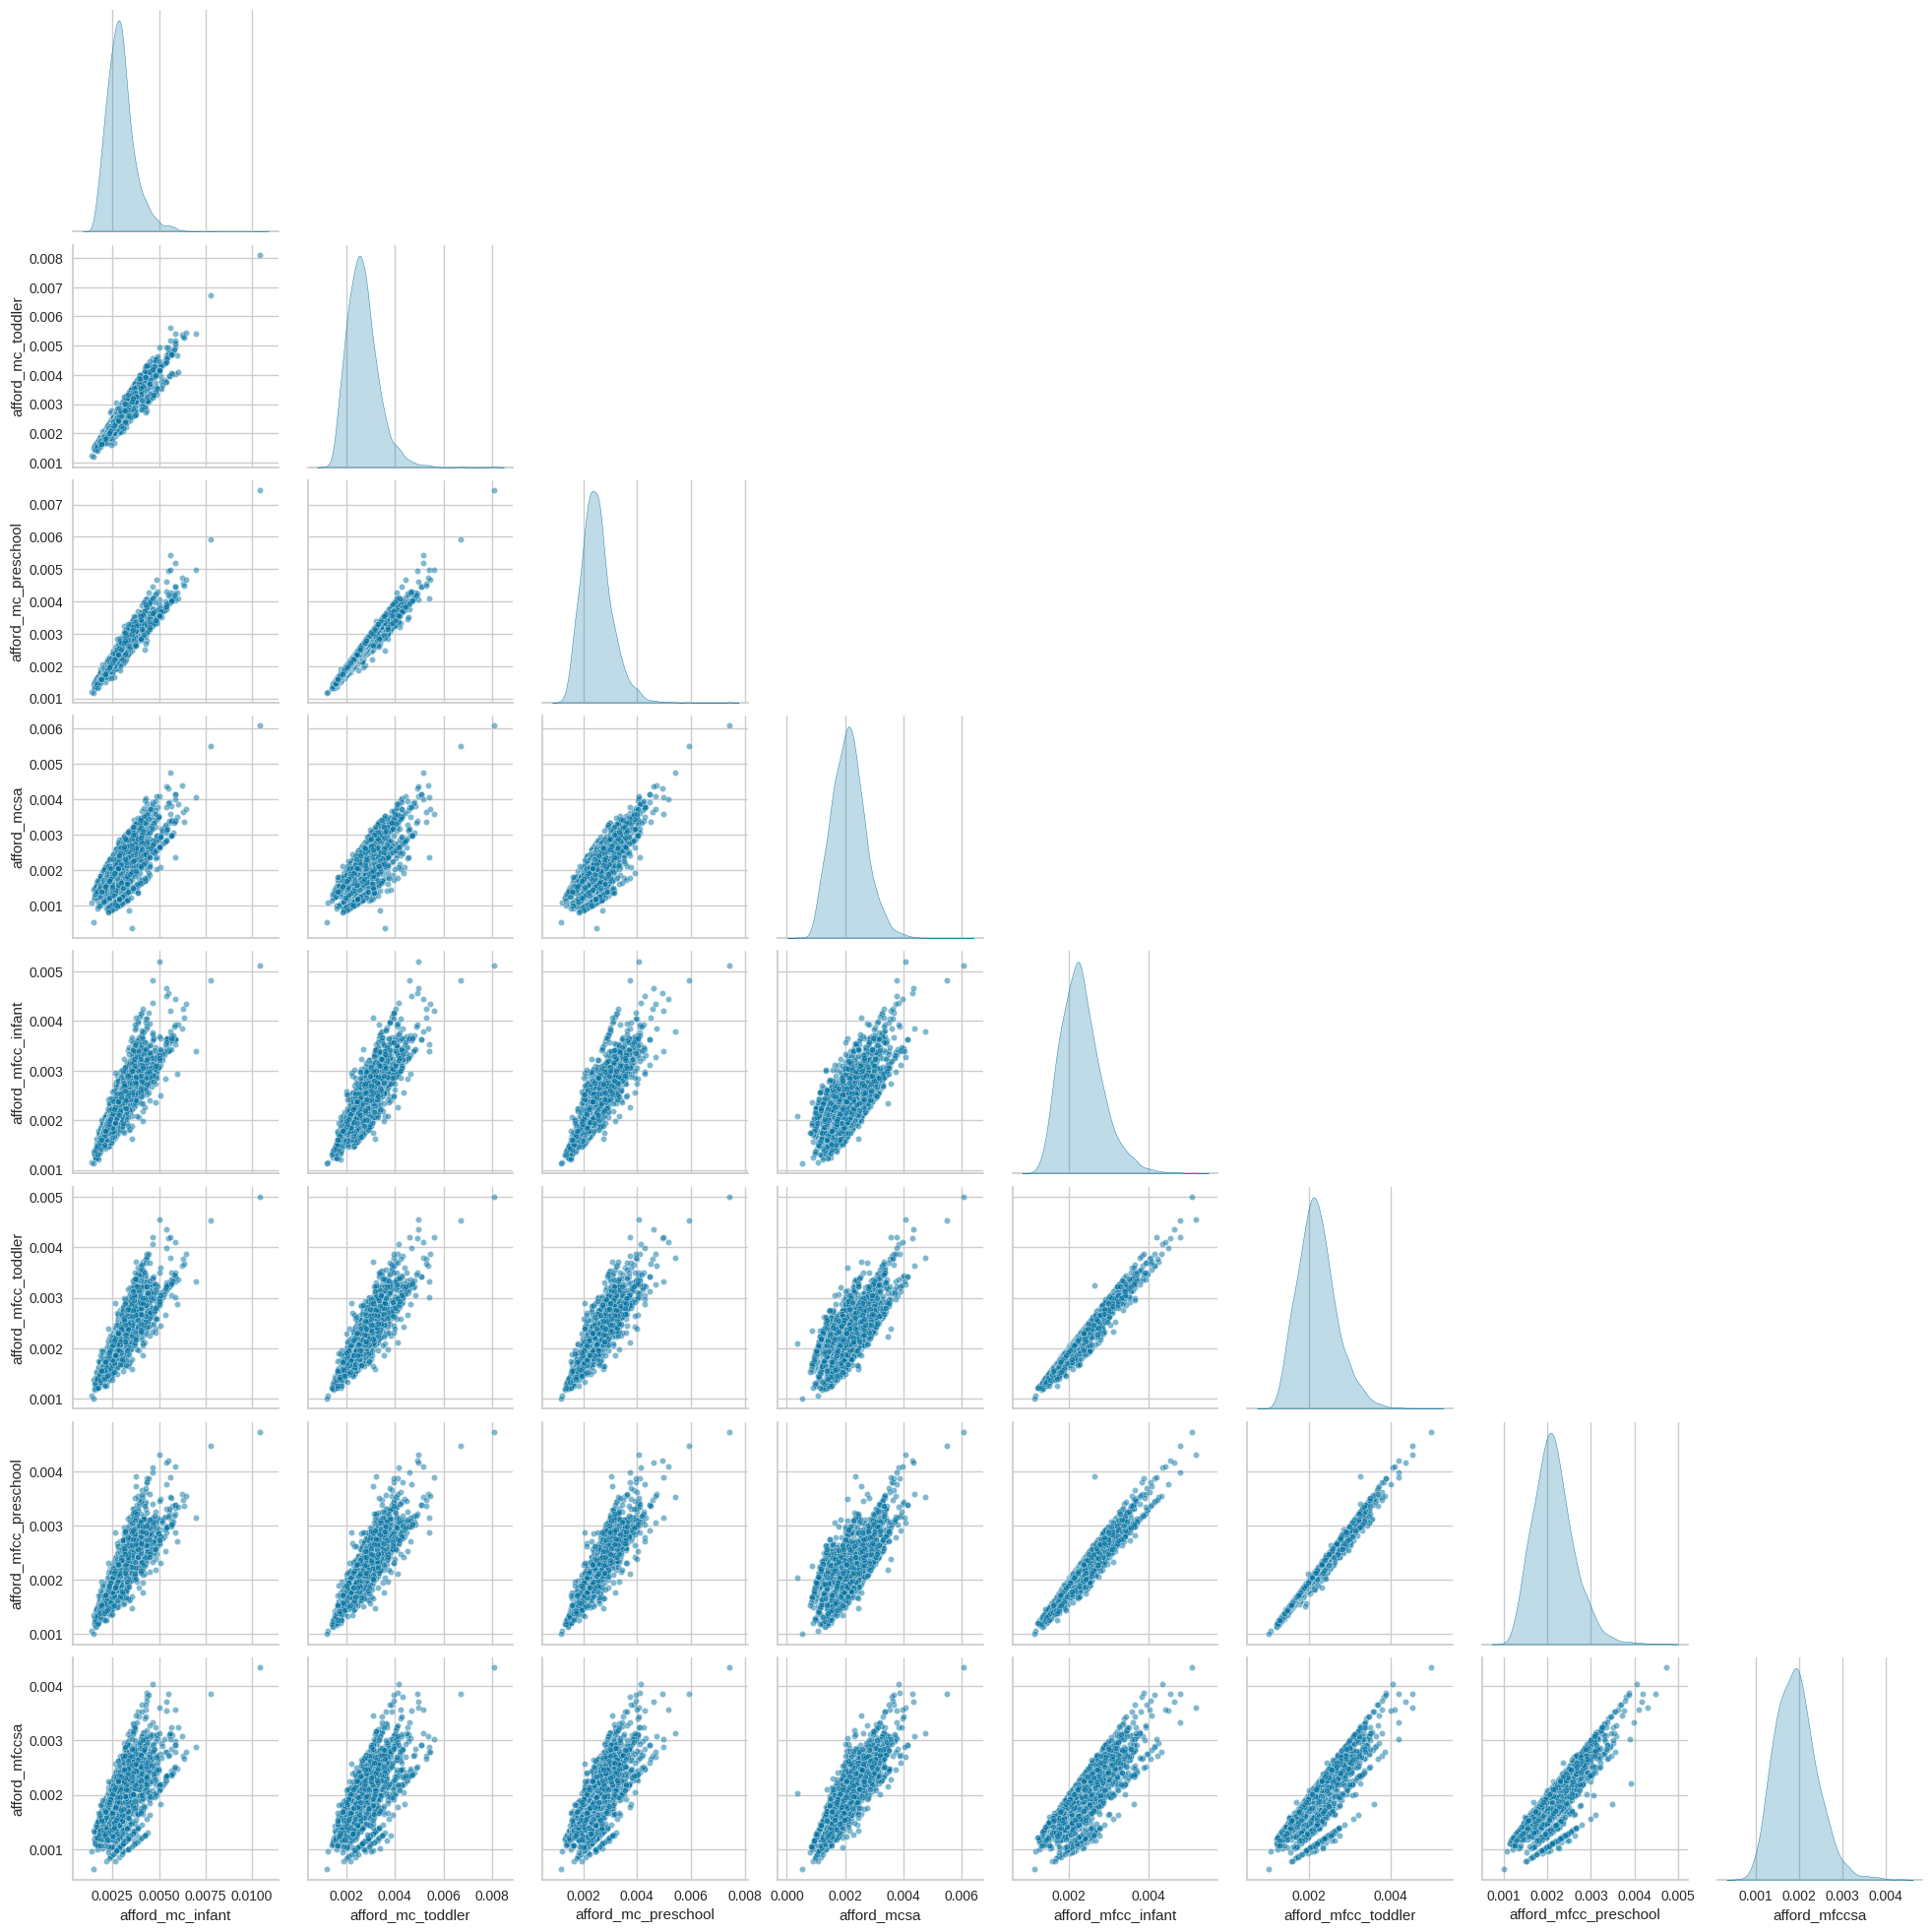

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

afford_df = childcare_county[afford_cols]

pairplot = sns.pairplot(
    afford_df,
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.5, "s": 20}
)

plt.show()


<Axes: >

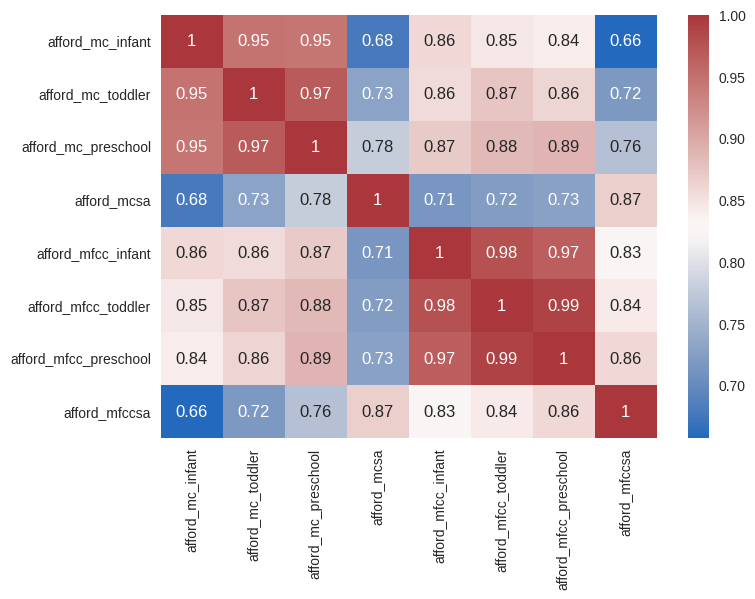

In [104]:
#plot correlation
affordabilty_df = childcare_county[afford_cols]
corr=affordabilty_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="vlag")

### Normalization

In [105]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
X_afford = childcare_county[afford_cols]

scaler = StandardScaler()
X_afford_scaled = scaler.fit_transform(X_afford)

X_afford_scaled = pd.DataFrame(
    X_afford_scaled,
    columns=afford_cols,
    index=X_afford.index
)

X_afford_scaled.head()


,afford_mc_infant,afford_mc_toddler,afford_mc_preschool,afford_mcsa,afford_mfcc_infant,afford_mfcc_toddler,afford_mfcc_preschool,afford_mfccsa
0,-1.384771,-1.220574,-1.531505,-0.956488,-1.140037,-0.973944,-0.934181,-0.490304
1,-1.239705,-1.046562,-1.164027,-0.663393,-0.792805,-0.598092,-0.569237,-0.124470
2,-0.764931,-0.477054,-0.448585,-0.051660,-0.359336,-0.133154,-0.126587,0.193491
3,-0.912294,-0.653820,-0.645199,-0.036879,-0.888769,-0.703337,-0.619332,-0.173392
4,-0.213374,0.184560,-0.005305,0.043215,-0.377361,-0.140501,-0.338647,-0.055434


## Clustering on original data(affordability)

### k-means

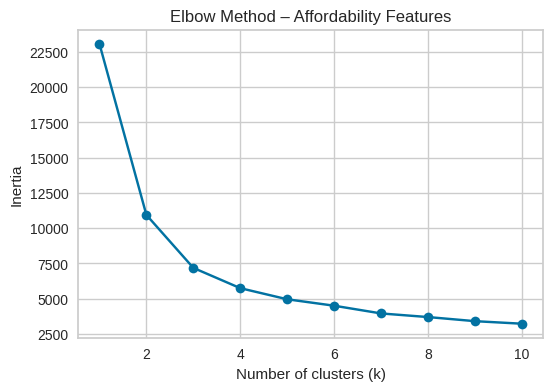

In [178]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_afford_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method – Affordability Features")
plt.show()

In [179]:
from sklearn.metrics import silhouette_score

for k in [2,3,4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_afford_scaled)
    score = silhouette_score(X_afford_scaled, labels)
    print(f"k={k}, silhouette score={score}")

k=2, silhouette score=0.4510041219634183
k=3, silhouette score=0.3858656192898696
k=4, silhouette score=0.3439983037001992


In [180]:
from sklearn.cluster import KMeans
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_afford_scaled)

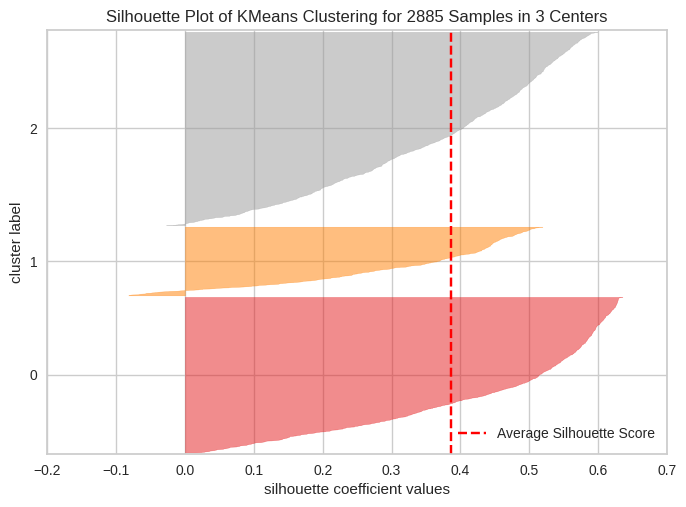

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 2885 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [181]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans

k = 3

model = KMeans(n_clusters=k, random_state=42)
visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_afford_scaled)
visualizer.show()

The silhouette plot for k=3 shows that most counties have positive silhouette coefficients, with an average score of approximately 0.39. While slightly lower than k=2, the clustering remains well-separated with minimal negative assignments. This suggests that k=3 provides a reasonably stable and interpretable segmentation of childcare affordability patterns.

In [182]:
from sklearn.cluster import KMeans

n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=42)

childcare_county["kmeans_afford_cluster"] = (kmeans.fit_predict(X_afford_scaled).astype(str))

print(childcare_county["kmeans_afford_cluster"].value_counts())

kmeans_afford_cluster
2    1336
0    1074
1     475
Name: count, dtype: int64


Hierarchical Clustering on scaled affordability

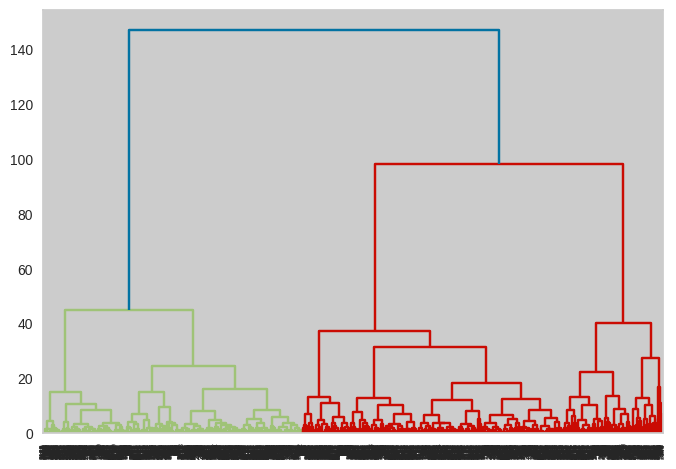

In [183]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(X_afford_scaled, 'ward')

_ = dendrogram(Z,)

In [184]:
from scipy.cluster.hierarchy import fcluster

n_clusters = 3
childcare_county["hier_afford_cluster"] = fcluster(Z, n_clusters, criterion="maxclust")

In [185]:
score = silhouette_score(
    X_afford_scaled,
    childcare_county["hier_afford_cluster"]
)

print("Silhouette score:", score)

Silhouette score: 0.367964262629554


See the proportion of counties in each affordability cluster

In [186]:
childcare_county["hier_afford_cluster"].value_counts(normalize=True)

,proportion
hier_afford_cluster,
1,0.419411
2,0.419411
3,0.161179


## PCA

In [187]:
!pip install psynlig -q

### PCA for Affordability feature set

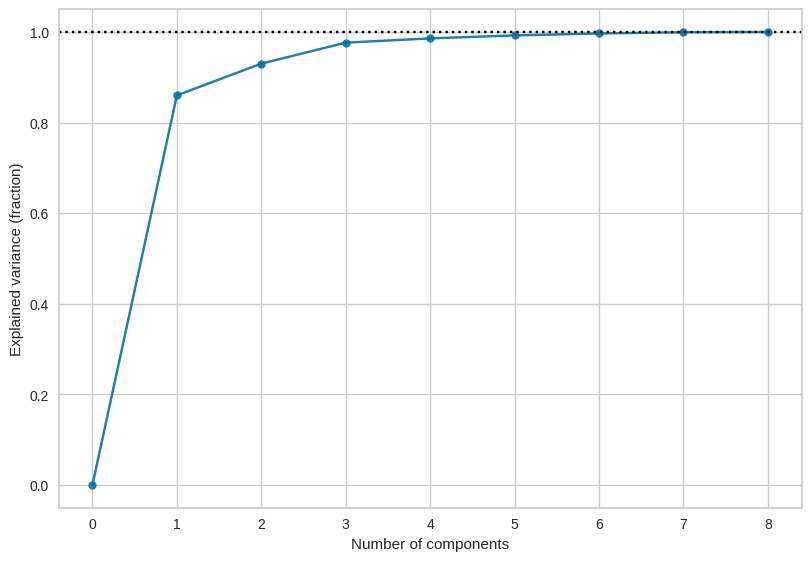

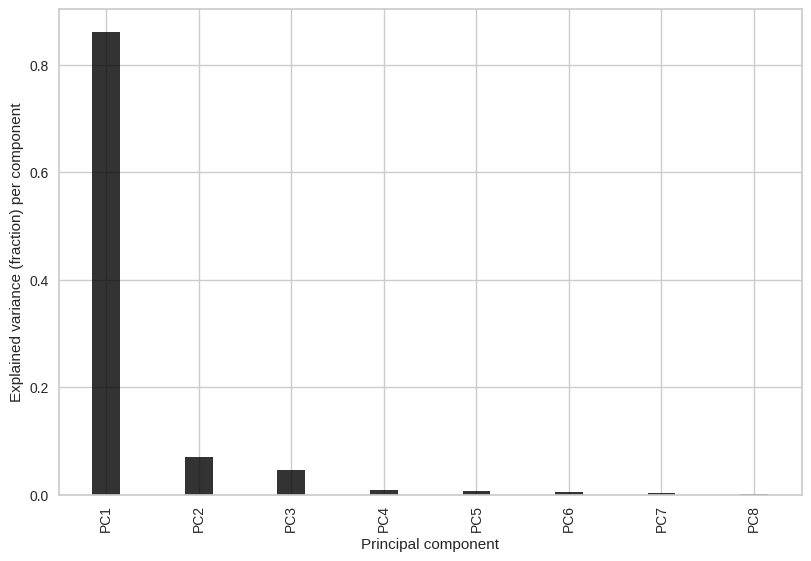

In [188]:
import numpy as np
from sklearn.decomposition import PCA
from psynlig import pca_explained_variance, pca_explained_variance_bar
import matplotlib.pyplot as plt
# Fit PCA (full)
pca_aff = PCA()
pca_aff.fit(X_afford_scaled)

# Prof-style plots (dots included)
_, ax = pca_explained_variance(pca_aff, marker='o', markersize=6, alpha=0.9)
plt.show()

pca_explained_variance_bar(pca_aff, width=0.3, alpha=0.8, color="black")
plt.show()

In [189]:
# Apply PCA with chosen components
pca_aff_model = PCA(n_components=2)
X_pca_aff = pca_aff_model.fit_transform(X_afford_scaled)

# check shape
X_pca_aff.shape

(2885, 2)

In [190]:
# Create the model
model = PCA(2)

#fit the data
model.fit(X_pca_aff)
transformed_data = model.transform(X_pca_aff)

## Clustering on PCA data(affordability)

### Hierarchical

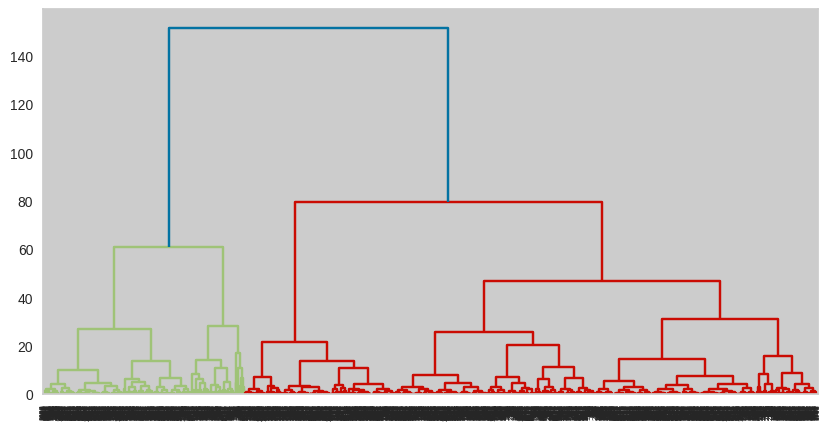

In [191]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt

Z = linkage(transformed_data, method='ward')

plt.figure(figsize=(10,5))
dendrogram(Z)
plt.show()

In [192]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in range(2,6):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = model.fit_predict(transformed_data)

    score = silhouette_score(transformed_data, labels)

    print(f"K={k}, Silhouette={score:.4f}")

K=2, Silhouette=0.4933
K=3, Silhouette=0.3798
K=4, Silhouette=0.3513
K=5, Silhouette=0.3063


### K-Means

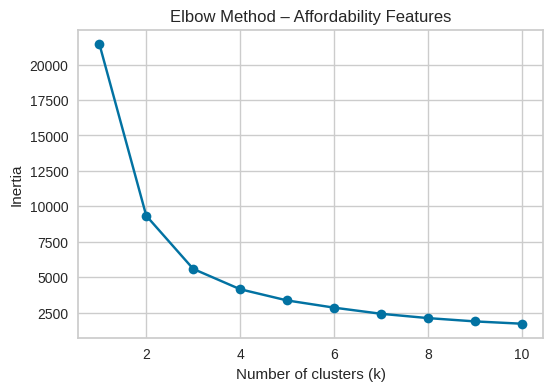

In [193]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(transformed_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method – Affordability Features")
plt.show()

In [194]:
from sklearn.metrics import silhouette_score

for k in range(2,6):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(transformed_data)
    score = silhouette_score(transformed_data, model.labels_)
    print(k, score)

2 0.49452137797650725
3 0.45031161673380793
4 0.41324000906579306
5 0.37750929761129715


In [195]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(transformed_data)

labels = kmeans.labels_

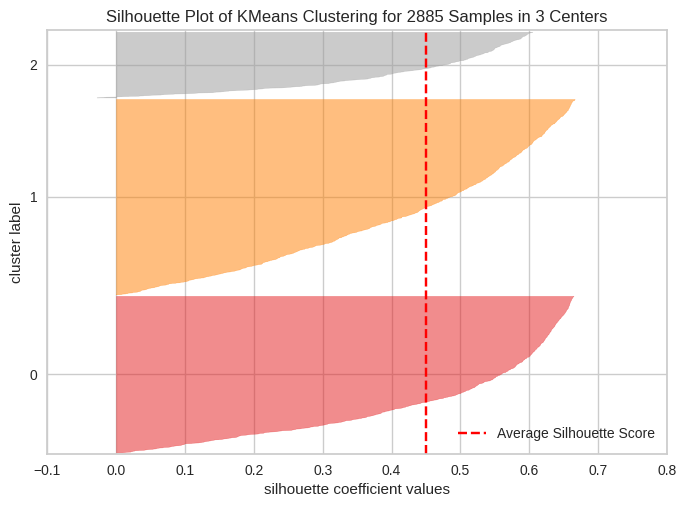

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 2885 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [196]:
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(3, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_pca_aff)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

In [197]:
from sklearn.cluster import KMeans

kmeans_model = KMeans(n_clusters=3, random_state=42)
labels = kmeans_model.fit_predict(X_pca_aff)

In [198]:
X_pca_aff.shape

(2885, 2)

In [199]:
pca_df = pd.DataFrame(X_pca_aff[:, :2], columns=['PC1', 'PC2'])
pca_df['cluster'] = labels
pca_df['county_fips_code'] = childcare_county['county_fips_code'].values

In [200]:
pca_df

,PC1,PC2,cluster,county_fips_code
0,-3.065618,0.580113,0,1001
1,-2.203849,0.731741,0,1003
2,-0.780168,0.686164,1,1005
3,-1.668797,0.690339,0,1007
4,-0.328854,0.052625,1,1009
...,...,...,...,...
2880,-2.800071,0.369872,0,56037
2881,3.666987,0.129022,2,56039
2882,-2.896342,0.372745,0,56041
2883,-1.627102,0.438901,0,56043


In [201]:
import plotly.express as px

fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color=pca_df['cluster'].astype(str),
    title='PCA Clusters (Affordability)'
)

fig.show()

In [202]:
pca_df['county_fips_code'] = childcare_county['county_fips_code'].values

In [206]:
cluster_table = pca_df[['county_fips_code', 'cluster']]

In [207]:
childcare_clean = childcare_clean.drop(columns=['cluster'], errors='ignore')

childcare_clean = childcare_clean.merge(
    cluster_table,
    on='county_fips_code',
    how='left'
)

In [208]:
childcare_clean

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,afford_mfcc_toddler,afford_mfcc_preschool,afford_mfccsa,cluster_x,PC1_x,PC2_x,cluster_y,PC1_y,PC2_y,cluster
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,0.001427,0.001392,0.001392,0,-3.065618,0.580113,0,-3.065618,0.580113,0
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,0.001451,0.001423,0.001423,0,-3.065618,0.580113,0,-3.065618,0.580113,0
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,0.001478,0.001456,0.001456,0,-3.065618,0.580113,0,-3.065618,0.580113,0
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,0.001578,0.001561,0.001561,0,-3.065618,0.580113,0,-3.065618,0.580113,0
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,0.001677,0.001666,0.001666,0,-3.065618,0.580113,0,-3.065618,0.580113,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23337,56045,2014,3.60,5.36,2.28,2.4,4.8,0.6,75.9,74.8,...,0.001937,0.001950,0.001976,0,-1.906399,0.433333,0,-1.906399,0.433333,0
23338,56045,2015,5.16,7.86,3.16,4.2,7.6,1.6,73.2,82.0,...,0.001812,0.001812,0.001812,0,-1.906399,0.433333,0,-1.906399,0.433333,0
23339,56045,2016,3.61,4.67,2.79,3.4,4.5,2.6,69.7,68.1,...,0.001901,0.001888,0.001863,0,-1.906399,0.433333,0,-1.906399,0.433333,0
23340,56045,2017,2.24,2.64,1.95,2.3,2.8,2.0,71.4,63.6,...,0.001812,0.001787,0.001740,0,-1.906399,0.433333,0,-1.906399,0.433333,0


## Analysis
Q3: How are childcare affordability clusters structurally associated with labor market and household characteristics?

In [216]:
import plotly.express as px

childcare_clean['cluster'] = childcare_clean['cluster'].astype(str)

fig = px.scatter(
    childcare_clean,
    x='afford_mfcc_infant',
    y='afford_mfcc_toddler',
    color='cluster',
    opacity=0.45,
    category_orders={'cluster': ['0','1','2']},
    color_discrete_map={
        '0': '#2ca02c',
        '1': '#ffcc00',
        '2': '#d62728'
    }
)

fig.update_traces(marker=dict(size=5))

fig.update_layout(
    legend_title_text='Cluster',
    font=dict(size=16)
)

fig.show()

**labor market**

` flfpr_20to64_under6` :labor force participation rate of the female population aged 20 to 64 years old who have children under 6 years old

In [152]:
childcare_clean.groupby('cluster')['flfpr_20to64_under6'].mean()

,flfpr_20to64_under6
cluster,
0,69.100541
1,68.916908
2,65.836087


**household structure**

`h_under6_both_work`: Number of households with children under 6 years old with two parents that are both working.

`h_under6_single_m`: Number of households with children under 6 years old with a single mother.



In [209]:
childcare_clean['single_m_share'] = (
    childcare_clean['h_under6_single_m'] /
    childcare_clean['households']
)

childcare_clean['dual_work_share'] = (
    childcare_clean['h_under6_both_work'] /
    childcare_clean['households']
)

In [210]:
childcare_clean.groupby('cluster')['dual_work_share'].mean()

,dual_work_share
cluster,
0,0.077383
1,0.065496
2,0.056655


In [211]:
childcare_clean.groupby('cluster')['single_m_share'].mean()

,single_m_share
cluster,
0,0.046686
1,0.050140
2,0.057792
